# 01 — Data Exploration

Explore the **WISDM smartphone accelerometer** dataset for the Mobile Sensor Intelligence platform.

Goals:
- Load and inspect raw sensor readings
- Understand activity labels and class balance
- Visualize accelerometer signals (x, y, z) over time

## Setup

The WISDM dataset and the raw files are at `data/wisdm-dataset-raw/raw`.

I'm using the phone and accelorator readings for now to experiement feature engineerig.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Users\ntaho\Desktop\sensor-intelligence


## Load data

WISDM raw files are comma-separated (`user,activity,timestamp,x,y,z;`). The trailing `;` is a line suffix, not the field delimiter.

In [2]:
def load_wisdm(path: Path) -> pd.DataFrame:
    """Load one WISDM accelerometer file into a tidy DataFrame."""
    df = pd.read_csv(
        path,
        sep=",",
        header=None,
        names=["user", "activity", "timestamp", "x", "y", "z"],
        engine="python",
    )
    # Each line ends with ';' which gets attached to the z value
    df["z"] = df["z"].astype(str).str.rstrip(";")
    df["user"] = pd.to_numeric(df["user"], errors="coerce").astype("Int64")
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    for col in ["x", "y", "z"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df.dropna().astype({"user": int}).reset_index(drop=True)


DATA_DIR = PROJECT_ROOT / "src" / "data" / "wisdm-dataset-raw" / "raw" / "phone" / "accel"

if not DATA_DIR.exists():
    raise FileNotFoundError(f"Dataset directory not found: {DATA_DIR}")

files = sorted(DATA_DIR.glob("*.txt"))
if not files:
    raise FileNotFoundError(f"No .txt files found in {DATA_DIR}")

df = pd.concat([load_wisdm(f) for f in files], ignore_index=True)

print(f"Loaded {len(files)} files")
print(f"Rows: {len(df):,}")
print(f"Users: {df['user'].nunique()}")
df.head()

Loaded 51 files
Rows: 4,804,403
Users: 51


,user,activity,timestamp,x,y,z
0,1600,A,252207666810782,-0.364761,8.793503,1.055084
1,1600,A,252207717164786,-0.879730,9.768784,1.016998
2,1600,A,252207767518790,2.001495,11.109070,2.619156
3,1600,A,252207817872794,0.450623,12.651642,0.184555
4,1600,A,252207868226798,-2.164352,13.928436,-4.422485


## Basic exploration

In [3]:
print(f"Rows:    {len(df):,}")
print(f"Users:   {df['user'].nunique()}")
print(f"Activities: {sorted(df['activity'].unique())}")
print()

Rows:    4,804,403
Users:   51
Activities: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'O', 'P', 'Q', 'R', 'S']



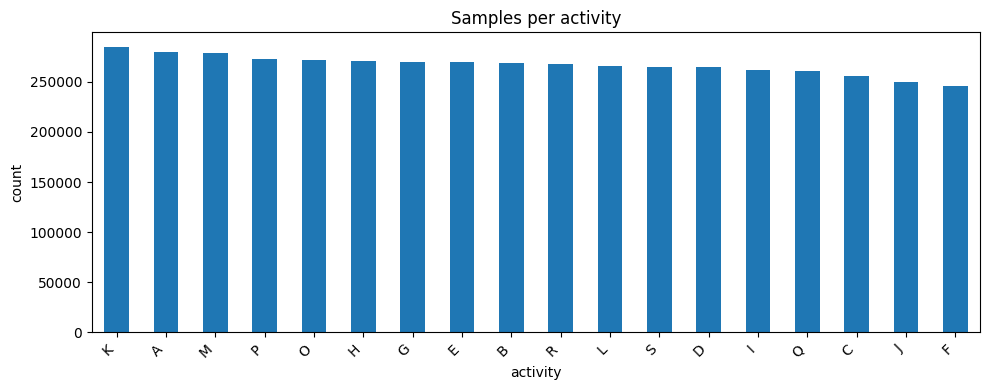

In [10]:
activity_counts = df["activity"].value_counts()
activity_counts.plot(kind="bar", title="Samples per activity", figsize=(10, 4))
plt.ylabel("count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Visualize accelerometer signals

Plot a 10-second window (200 samples @ 20 Hz) of x/y/z readings for **5 users** performing **walking** (activity `A`). This mirrors the `SensorSample` schema used by the API (`timestamp`, `x`, `y`, `z`).

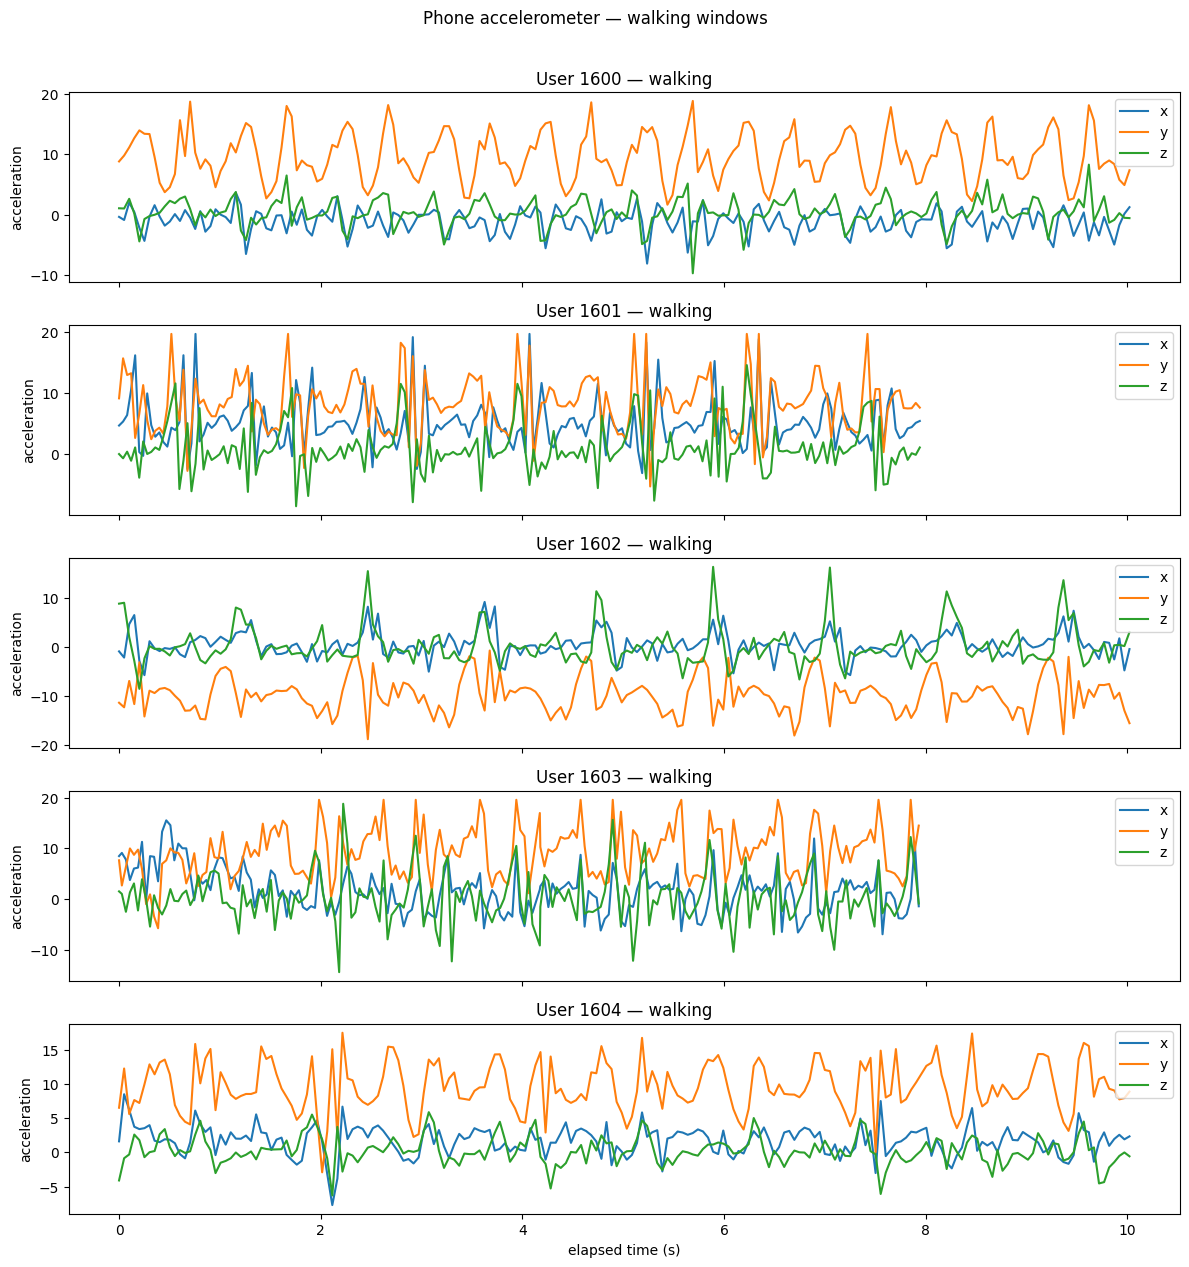

In [4]:
WALKING = "A"  # see activity_key.txt
WINDOW_SIZE = 200  # 10 seconds at 20 Hz (matches WISDM ARFF window size)
NUM_USERS = 5

sample_users = (
    df.loc[df["activity"] == WALKING, "user"]
    .drop_duplicates()
    .head(NUM_USERS)
    .tolist()
)

fig, axes = plt.subplots(NUM_USERS, 1, figsize=(12, 2.5 * NUM_USERS), sharex=True)
if NUM_USERS == 1:
    axes = [axes]

for ax, user in zip(axes, sample_users):
    window = (
        df[(df["user"] == user) & (df["activity"] == WALKING)]
        .sort_values("timestamp")
        .head(WINDOW_SIZE)
    )
    # Timestamps are nanoseconds; plot elapsed seconds from window start
    elapsed_s = (window["timestamp"] - window["timestamp"].iloc[0]) / 1e9

    ax.plot(elapsed_s, window["x"], label="x")
    ax.plot(elapsed_s, window["y"], label="y")
    ax.plot(elapsed_s, window["z"], label="z")
    ax.set_title(f"User {user} — walking")
    ax.set_ylabel("acceleration")
    ax.legend(loc="upper right")

axes[-1].set_xlabel("elapsed time (s)")
fig.suptitle("Phone accelerometer — walking windows", y=1.01)
plt.tight_layout()
plt.show()

## Sitting activity windows

Compare the same 10-second window layout for **5 users** performing **sitting** (activity `D`). Sitting should show much lower variance than walking — a good sanity check before feature engineering.

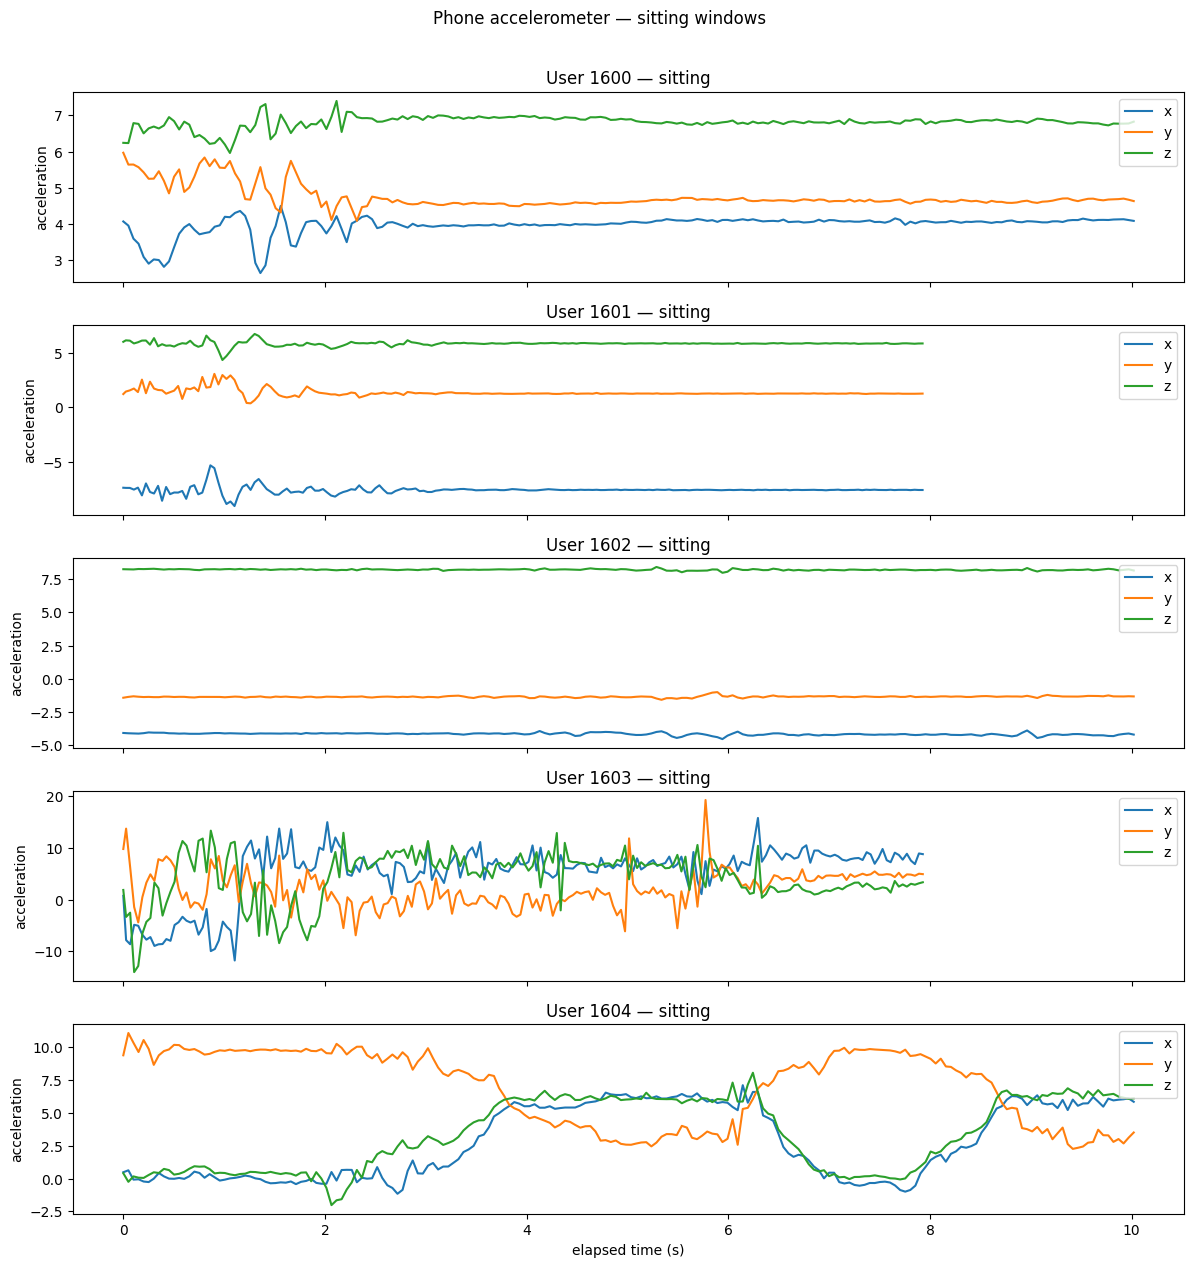

In [5]:
SITTING = "D"  # see activity_key.txt
WINDOW_SIZE = 200
NUM_USERS = 5

sitting_users = (
    df.loc[df["activity"] == SITTING, "user"]
    .drop_duplicates()
    .head(NUM_USERS)
    .tolist()
)

fig, axes = plt.subplots(NUM_USERS, 1, figsize=(12, 2.5 * NUM_USERS), sharex=True)
if NUM_USERS == 1:
    axes = [axes]

for ax, user in zip(axes, sitting_users):
    window = (
        df[(df["user"] == user) & (df["activity"] == SITTING)]
        .sort_values("timestamp")
        .head(WINDOW_SIZE)
    )
    elapsed_s = (window["timestamp"] - window["timestamp"].iloc[0]) / 1e9

    ax.plot(elapsed_s, window["x"], label="x")
    ax.plot(elapsed_s, window["y"], label="y")
    ax.plot(elapsed_s, window["z"], label="z")
    ax.set_title(f"User {user} — sitting")
    ax.set_ylabel("acceleration")
    ax.legend(loc="upper right")

axes[-1].set_xlabel("elapsed time (s)")
fig.suptitle("Phone accelerometer — sitting windows", y=1.01)
plt.tight_layout()
plt.show()

## Resultant acceleration

Raw x/y/z axes depend on **phone orientation**, so sitting traces can look very different across users even when everyone is still. **Resultant acceleration** combines the three axes:

$$\text{resultant} = \sqrt{x^2 + y^2 + z^2}$$

For stationary activities this should stay near **~9.8 m/s²** (gravity) regardless of orientation. Walking should oscillate around that value. Each plot still uses the **first 200 readings** (~10 s) of the activity window.

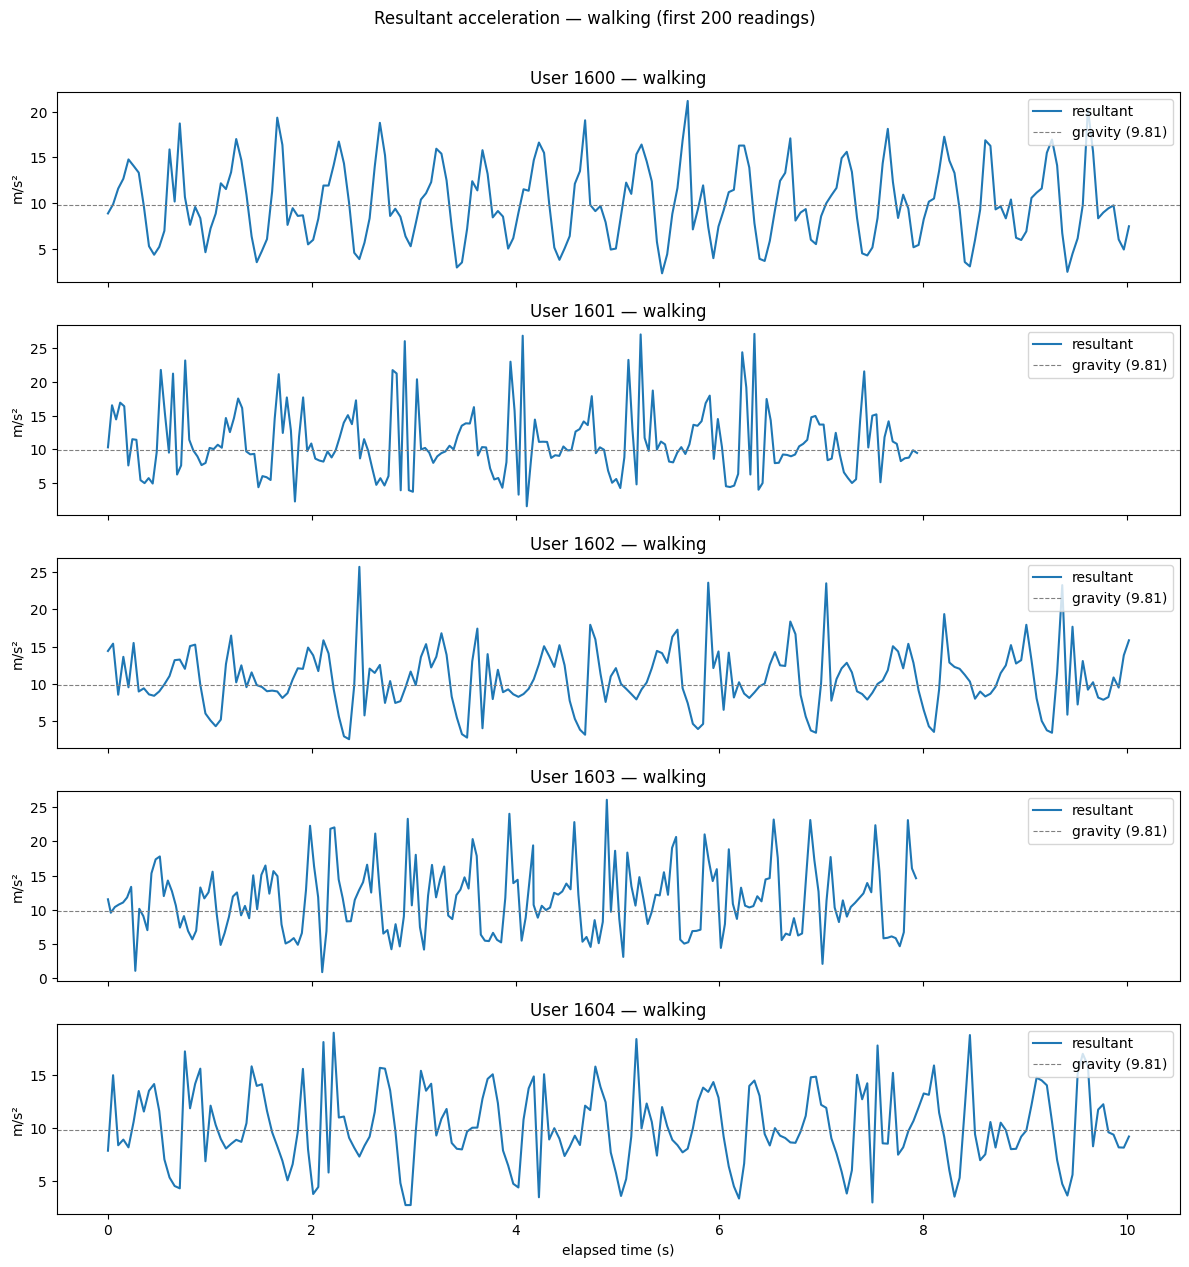

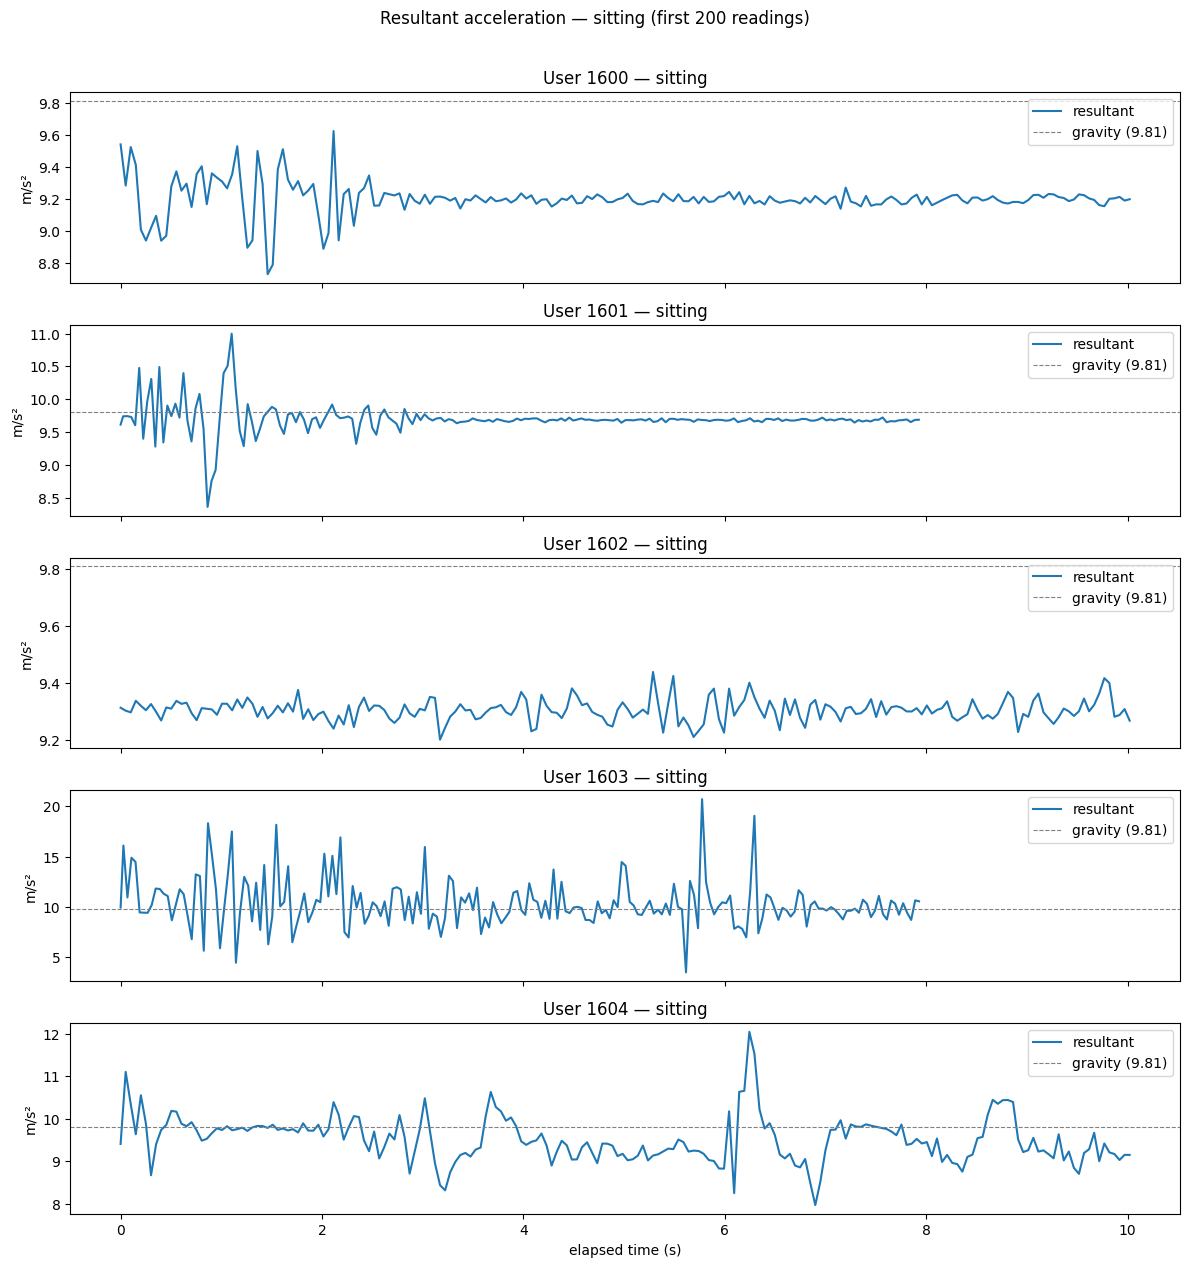

In [6]:
import numpy as np

WINDOW_SIZE = 200
GRAVITY_MS2 = 9.81


def plot_resultant_windows(activity_code: str, activity_name: str, users: list[int]) -> None:
    """Plot resultant acceleration for the first WINDOW_SIZE readings per user."""
    fig, axes = plt.subplots(len(users), 1, figsize=(12, 2.5 * len(users)), sharex=True)
    if len(users) == 1:
        axes = [axes]

    for ax, user in zip(axes, users):
        window = (
            df[(df["user"] == user) & (df["activity"] == activity_code)]
            .sort_values("timestamp")
            .head(WINDOW_SIZE)
        )
        elapsed_s = (window["timestamp"] - window["timestamp"].iloc[0]) / 1e9
        resultant = np.sqrt(window["x"] ** 2 + window["y"] ** 2 + window["z"] ** 2)

        ax.plot(elapsed_s, resultant, label="resultant")
        ax.axhline(GRAVITY_MS2, color="gray", linestyle="--", linewidth=0.8, label="gravity (9.81)")
        ax.set_title(f"User {user} — {activity_name}")
        ax.set_ylabel("m/s²")
        ax.legend(loc="upper right")

    axes[-1].set_xlabel("elapsed time (s)")
    fig.suptitle(
        f"Resultant acceleration — {activity_name} (first {WINDOW_SIZE} readings)",
        y=1.01,
    )
    plt.tight_layout()
    plt.show()


walking_users = (
    df.loc[df["activity"] == "A", "user"].drop_duplicates().head(5).tolist()
)
sitting_users = (
    df.loc[df["activity"] == "D", "user"].drop_duplicates().head(5).tolist()
)

plot_resultant_windows("A", "walking", walking_users)
plot_resultant_windows("D", "sitting", sitting_users)

## Prepare 200-reading windows

Group by `user` and `activity`, sort by `timestamp`, then slice each segment into **non-overlapping 200-reading windows** (10 s @ 20 Hz). A 3-minute activity block (~3,600 readings) yields about **18 windows** per user–activity pair. Leftover readings shorter than 200 are dropped.

In [7]:
WINDOW_SIZE = 200


def make_windows(group: pd.DataFrame) -> pd.DataFrame:
    """Split one user-activity segment into non-overlapping 200-reading windows."""
    user, activity = group.name
    group = group.sort_values("timestamp").reset_index(drop=True)

    n_windows = len(group) // WINDOW_SIZE
    if n_windows == 0:
        return pd.DataFrame()

    windows = []
    for window_idx in range(n_windows):
        start = window_idx * WINDOW_SIZE
        window = group.iloc[start : start + WINDOW_SIZE].copy()
        window["user"] = user
        window["activity"] = activity
        window["window_idx"] = window_idx
        windows.append(window)

    return pd.concat(windows, ignore_index=True)


windows_df = (
    df.groupby(["user", "activity"], group_keys=False)
    .apply(make_windows, include_groups=False)
    .reset_index(drop=True)
)

window_summary = (
    windows_df.groupby(["user", "activity", "window_idx"])
    .size()
    .reset_index(name="readings")
)

print(f"Raw readings:     {len(df):,}")
print(f"Windowed readings: {len(windows_df):,}")
print(f"Total windows:    {len(window_summary):,}")
print(f"Readings per window:")
print(window_summary["readings"].value_counts().to_string())
print()
windows_df.head()

Raw readings:     4,804,403
Windowed readings: 4,679,400
Total windows:    23,397
Readings per window:
readings
200    23397



,timestamp,x,y,z,user,activity,window_idx
0,252207666810782,-0.364761,8.793503,1.055084,1600,A,0
1,252207717164786,-0.879730,9.768784,1.016998,1600,A,0
2,252207767518790,2.001495,11.109070,2.619156,1600,A,0
3,252207817872794,0.450623,12.651642,0.184555,1600,A,0
4,252207868226798,-2.164352,13.928436,-4.422485,1600,A,0


In [8]:
# Quick sanity check: windows per user-activity (expect ~18 for a full 3-min block)
window_summary.groupby(["user", "activity"]).size().describe()

count    910.000000
mean      25.710989
std       11.683533
min       17.000000
25%       17.000000
50%       18.000000
75%       44.000000
max       89.000000
dtype: float64

## Feature engineering table

`build_features_table()` collapses `windows_df` into **one row per window** with metadata (`user`, `activity`, `window_idx`) plus engineered features.

**Group 1 — binned distributions:** `X0`–`X9`, `Y0`–`Y9`, `Z0`–`Z9` (fractions sum to ~1.0 per axis)

**Group 2 — averages:** `XAVG`, `YAVG`, `ZAVG` (mean per axis; captures device orientation)

In [9]:
import sys

# Jupyter runs from notebooks/, so add project root for src.* imports
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Reload project modules when src/ code changes during development
for module_name in list(sys.modules):
    if module_name.startswith("src.features"):
        del sys.modules[module_name]

from src.features.window_features import build_features_table

# One row per window: metadata + binned features + averages
features_df = build_features_table(windows_df)

print(f"Feature table shape: {features_df.shape}")
print(f"First columns: {list(features_df.columns[:5])}")
print(f"Last columns:  {list(features_df.columns[-3:])}")
print()
features_df.head()

Feature table shape: (23397, 36)
First columns: ['user', 'activity', 'window_idx', 'X0', 'X1']
Last columns:  ['XAVG', 'YAVG', 'ZAVG']



,user,activity,window_idx,X0,X1,X2,X3,X4,X5,X6,...,Z3,Z4,Z5,Z6,Z7,Z8,Z9,XAVG,YAVG,ZAVG
0,1600,A,0,0.005,0.010,0.050,0.085,0.140,0.190,0.250,...,0.050,0.115,0.485,0.175,0.115,0.01,0.010,-1.172309,9.570639,0.406854
1,1600,A,1,0.030,0.025,0.060,0.065,0.125,0.215,0.230,...,0.095,0.330,0.245,0.175,0.080,0.00,0.005,-1.504971,9.565831,0.432132
2,1600,A,2,0.030,0.015,0.045,0.095,0.260,0.245,0.245,...,0.095,0.340,0.190,0.145,0.085,0.03,0.015,-1.686600,9.385923,0.474974
3,1600,A,3,0.040,0.055,0.060,0.090,0.135,0.170,0.200,...,0.130,0.395,0.150,0.150,0.050,0.02,0.020,-1.746612,9.542974,0.495973
4,1600,A,4,0.020,0.025,0.075,0.095,0.180,0.215,0.255,...,0.235,0.315,0.195,0.100,0.035,0.01,0.010,-1.077078,9.637107,0.619938


## Baseline model and saved artifacts

Train a RandomForest baseline, report accuracy/F1, and save:
- `data/processed/windows_phone_accel.pkl` — window groupings for new features tomorrow
- `data/processed/features_phone_accel.pkl` — current feature table
- `models/random_forest_baseline.joblib` — trained baseline model

In [15]:
for module_name in list(sys.modules):
    if module_name.startswith("src."):
        del sys.modules[module_name]

from src.data.artifacts import save_features_df, save_model, save_windows_df
from src.features.window_features import FEATURE_COLUMNS
from src.models.baseline import train_random_forest_baseline

saved_windows = save_windows_df(windows_df, PROJECT_ROOT)
saved_features = save_features_df(features_df, PROJECT_ROOT)

model, metrics = train_random_forest_baseline(features_df, FEATURE_COLUMNS)
saved_model = save_model(model, PROJECT_ROOT)

print("Saved artifacts:")
print(f"  windows:  {saved_windows}")
print(f"  features: {saved_features}")
print(f"  model:    {saved_model}")
print()
print(f"Accuracy:   {metrics.accuracy:.4f}")
print(f"F1 (macro): {metrics.f1_macro:.4f}")

Saved artifacts:
  windows:  c:\Users\ntaho\Desktop\sensor-intelligence\data\processed\windows_phone_accel.pkl
  features: c:\Users\ntaho\Desktop\sensor-intelligence\data\processed\features_phone_accel.pkl
  model:    c:\Users\ntaho\Desktop\sensor-intelligence\models\random_forest_baseline.joblib

Accuracy:   0.5419
F1 (macro): 0.5338


## Next steps

- Add more ARFF-style feature groups (std, resultant, etc.) and rebuild `features_df` from saved `windows_phone_accel.pkl`
- Improve baseline (user-level splits, hyperparameter tuning)
- Wire trained model into the FastAPI `/predict` endpoint